# RL Group Project: Starter Notebook
## Clinical Treatment Optimisation: Sepsis ICU Management

**Master in Data Science & Advanced Analytics — Reinforcement Learning Course**

This project is structured in two stages of increasing complexity.

- In **Configuration A**, you will work with a tabular Sepsis MDP, where the state and action spaces are small enough to apply classical RL methods directly. 

- In **Configuration B**, you will move to a continuous-observation ICU environment that is clinically grounded and significantly more challenging. 

Three realistic failure modes are present in Configuration B, each reflecting a real scenario encountered in clinical AI deployments. The first is episodic observation noise, where monitoring equipment occasionally malfunctions. The second is episodic missing observations, representing situations where lab results are simply unavailable for an entire episode. The third is acute clinical events, which are sudden and irreversible patient deteriorations that occur independently of any treatment given.


---
### Group Members
Fill in before submitting:

Name of the Group: Group 5

```
Student 1: Miguel Matos, 20221925
Student 2: Ana Margarida Macedo, 20250405
Student 3: Mehmet Karaca, 20250344
Student 4: Veronica Mendes, 20221945
Student 5: Luis Mendes, 20221949
```


## 0. Setup & Imports


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
import os
import sys

# Add project root to sys.path so that 'envs' package is importable
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

os.makedirs('plots', exist_ok=True)
PLOTS_DIR = 'plots'

SEED = 42
np.random.seed(SEED)

#  Import constants and env factory from env_setup.py 
from envs.env_setup import (
    ENV_ID, N_STATES, N_ACTIONS, STATE_SURVIVED, STATE_DIED,
    GAMMA, INTENSITY, SOFA_BIAS, LAM,
    make_sepsis_env,
)

print(f'ICU-Sepsis-v2 | States: {N_STATES} | Actions: {N_ACTIONS}')
print(f'Terminal states: {STATE_SURVIVED} (survived, r=+1)  {STATE_DIED} (died, r=0)')
print('Setup complete!')


ICU-Sepsis-v2 | States: 716 | Actions: 25
Terminal states: 714 (survived, r=+1)  713 (died, r=0)
Setup complete!


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [5]:
# Configuration already loaded from env_setup.py
# env_setup.py defines: SOFA_BIAS=5.0, LAM=0.02, INTENSITY, make_sepsis_env()
print(f'Required config: sofa_bias={SOFA_BIAS}, lam={LAM}')

Required config: sofa_bias=5.0, lam=0.02


---
## 1. Explore the Environment

Before writing any algorithm, take time to understand the MDP you are working with. The insights you gain here should inform your report's Methodology section.

`ICU-Sepsis-v2` is a benchmark MDP constructed from real MIMIC-III patient data. Each episode represents the trajectory of one ICU patient. The agent observes a discrete integer state (ranging from 0 to 715) and must select one of 25 treatment actions corresponding to combinations of vasopressor and IV fluid dose levels. The reward signal is sparse: **+1 at survival, 0 at death**, with 0 for all intermediate steps and a discount factor γ = 1. In this project, `env_setup.py` additionally applies a small per-step treatment intensity penalty `lam=0.02` — so mean return will always be slightly lower than survival rate.


In [6]:
#  Instantiate and inspect the raw environment 
env = make_sepsis_env()
obs, info = env.reset(seed=SEED)

print(f'Observation space : {env.observation_space} discrete integer state')
print(f'Action space      : {env.action_space}')
print(f'Initial state     : {obs}')
print()

#  Extract the full MDP model 
raw = env.unwrapped
P = raw._tx_mat    # shape (716, 25, 716) — P[s,a,s'] = P(s'|s,a)
R_sasp = raw._r_mat                    # (716, 25, 716) — R[s, a, s']
R = (P * R_sasp).sum(axis=2)          # (716, 25)      — E[r | s, a]

print(f'Transition matrix P : {P.shape}  (S × A × S\')')
print(f'Reward matrix R     : {R.shape}  (S × A)')
print(f'Reward range        : [{R.min():.3f}, {R.max():.3f}]')
print()


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Observation space : Discrete(716) discrete integer state
Action space      : Discrete(25)
Initial state     : 559

Transition matrix P : (716, 25, 716)  (S × A × S')
Reward matrix R     : (716, 25)  (S × A)
Reward range        : [-0.020, 0.708]



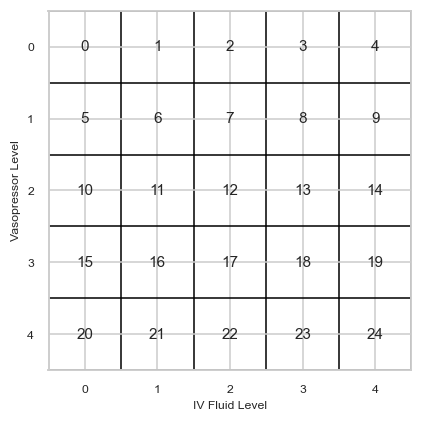

In [10]:
fig, ax = plt.subplots(figsize=(4, 4))

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels([str(i) for i in range(5)], fontsize=8)
ax.set_yticklabels([str(i) for i in range(5)], fontsize=8)
ax.set_xlabel('IV Fluid Level', fontsize=8)
ax.set_ylabel('Vasopressor Level', fontsize=8)

ax.set_xlim(-0.5, 4.5)
ax.set_ylim(4.5, -0.5)   # put 0 at the bottom
ax.set_facecolor('white')

# draw grid lines
ax.set_xticks(np.arange(-0.5, 5, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 5, 1), minor=True)
ax.grid(which='minor', color='black', linestyle='-', linewidth=1)
ax.tick_params(which='minor', length=0)

for r in range(5):
    for c in range(5):
        ax.text(c, r, str(action_grid[r, c]),
                ha='center', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Config A — Tabular Methods

With 716 discrete states and 25 actions, the Q-table has shape `(716, 25)`, totalling 17,900 entries. This size is entirely manageable in memory, which is precisely what motivates the use of tabular algorithms.


---
# Config B: RL on the Clinical ICU-Sepsis Environment

In Config A, patient state was represented as a discrete integer produced by discretising a set of clinical measurements into a small number of categories. **Config B uses the full ICU-Sepsis environment**, also built from MIMIC-III data, but with two fundamental changes that make the problem substantially harder.

**Change 1 — Continuous observations.**
The agent now receives a **47-dimensional continuous feature vector** instead of a single discrete index. This vector contains the actual normalised physiological measurements used in the original Komorowski et al. (2018) AI Clinician study, including SOFA score, heart rate, lactate, blood pressure, creatinine, and 42 other clinical variables.

With continuous observations, a tabular Q-table is no longer feasible: it would require one entry per unique float vector, making it effectively infinite. 

**Change 2 — Clinical reality wrappers.**
Config B injects three orthogonal failure modes that reflect challenges faced by real clinical AI deployments.

The first wrapper, `EpisodicNoisyObsEnv`, models episodic monitor malfunction. When active, the observations received by the agent are corrupted by noise for the entire episode, testing robustness to measurement error.

The second wrapper, `EpisodicMissingObsEnv`, models situations where lab results are unavailable for a full episode. This tests how well the agent handles partial observability.

The third wrapper, `AcuteEventEnv`, introduces rare, sudden patient deterioration events such as cardiac arrest or acute organ failure. These occur independently of any treatment decision and represent irreducible stochasticity in the environment.


Key environment properties for Config B:
- **Actions**: 25 total (5 vasopressor levels × 5 IV fluid dose levels)
- **Reward**: +1.0 at survival, 0.0 at death, plus a small treatment intensity penalty (lam = 0.02)
- **Observation**: `Box(47,)`, a normalised physiological feature vector, potentially noisy or incomplete

## Setup: Clinical ICU-Sepsis Environment


In [7]:
#  Import Clinical Reality Wrappers from wrappers.py 

from envs.wrappers import (
    EpisodicNoisyObsEnv,
    EpisodicMissingObsEnv,
    AcuteEventEnv,
    make_clinical_env,
)

print('Clinical reality wrappers imported from wrappers.py:')
print('  EpisodicNoisyObsEnv   : episodic monitor malfunction')
print('  EpisodicMissingObsEnv : episodic missing lab values')
print('  AcuteEventEnv         : rare sudden patient death')
print()
print('Required Config B env: make_clinical_env() with default parameters')


Clinical reality wrappers imported from wrappers.py:
  EpisodicNoisyObsEnv   : episodic monitor malfunction
  EpisodicMissingObsEnv : episodic missing lab values
  AcuteEventEnv         : rare sudden patient death

Required Config B env: make_clinical_env() with default parameters


In [8]:
#  Verify wrappers and random baseline on clinical environment 
import gymnasium as gym

env_clinical = make_clinical_env()
obs, info = env_clinical.reset(seed=SEED)

print('Clinical environment loaded successfully!')
print(f'Observation space : {env_clinical.observation_space}')
print(f'Action space      : {env_clinical.action_space}')
print(f'Info keys         : {list(info.keys())}')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Clinical environment loaded successfully!
Observation space : Box(-inf, inf, (47,), float32)
Action space      : Discrete(25)
Info keys         : ['admissible_actions', 'state_vector', 'sofa_score', 'noisy_episode', 'missing_features']
